### 模块二：用户流失、留存与动态复购策略
本模块聚焦用户生命周期分析：
1. 全站用户留存率衰减曲线（次日~7日）
2. 购买行为路径分布（用户从浏览到购买的典型路径）
3. 复购周期建模与流失预警线设定

导入依赖、加载数据，统一ID格式与日期提取

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')

df_sample = pd.read_parquet(os.path.join(DATA_DIR, 'taobao_sample_50k.parquet'))

# 统一ID格式为字符串，方便后续分组处理
df_sample['user_id'] = df_sample['user_id'].astype(str)
df_sample['behavior_type'] = df_sample['behavior_type'].astype(str)

# 提取日期（天）
df_sample['date'] = df_sample['timestamp'].dt.date

1.用户留存分析（次日～7日留存率）
计算各首访日期用户群组在首访后第 1 天至第 7 天的留存率，再取所有群组的平均值，
输出平均留存率曲线所需的数据表。

In [7]:
# 每个用户的首访日期
user_first_date = df_sample.groupby('user_id')['date'].min().reset_index().rename(columns={'date': 'first_date'})

# 将用户活跃日期与首访日期关联，计算距首访天数
df_retention = pd.merge(df_sample[['user_id', 'date']].drop_duplicates(), user_first_date, on='user_id')
df_retention['days_diff'] = (df_retention['date'] - df_retention['first_date']).apply(lambda x: x.days)

# 构建留存矩阵：行=首访日期，列=距首访天数，值=该天活跃的用户数
retention_pivot = df_retention.groupby(['first_date', 'days_diff']).size().unstack(fill_value=0)

# 留存率计算
cohort_sizes = retention_pivot[0]
retention_matrix = retention_pivot.divide(cohort_sizes, axis=0) * 100

# 提取 Day 1 至 Day 7 的平均留存率
retention_days = range(1, 8)
avg_retention_rates = [retention_matrix[day].mean() for day in retention_days]

df_avg_retention = pd.DataFrame({
    '留存天数': [f'Day {i}' for i in retention_days],
    '平均留存率(%)': np.round(avg_retention_rates, 2)
})

df_avg_retention.to_csv(os.path.join(DATA_DIR, 'output_avg_retention_1to7.csv'), index=False)
df_avg_retention

,留存天数,平均留存率(%)
0,Day 1,71.71
1,Day 2,65.63
2,Day 3,57.10
3,Day 4,49.20
4,Day 5,41.29
5,Day 6,32.91
6,Day 7,23.41


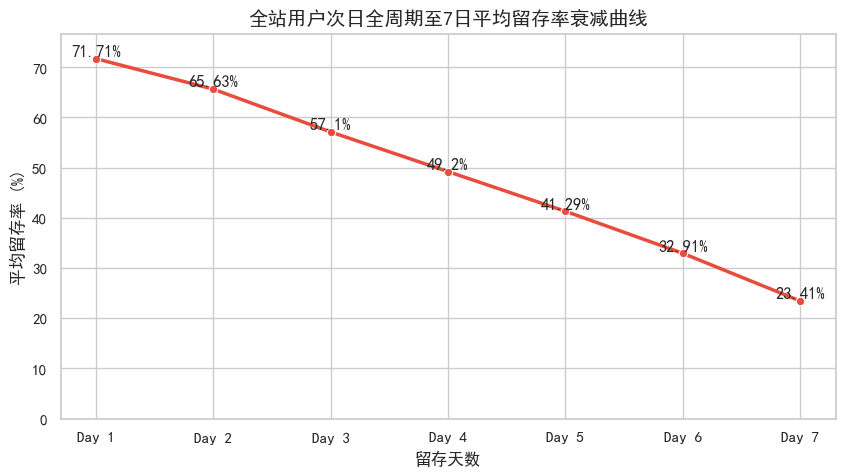

In [8]:
# 绘制用户留存率衰减曲线图
plt.figure(figsize=(10, 5))
sns.lineplot(x='留存天数', y='平均留存率(%)', data=df_avg_retention, marker='o', color='#e74c3c', linewidth=2.5)

for index, row in df_avg_retention.iterrows():
    plt.text(index, row['平均留存率(%)'] + 0.5, f"{row['平均留存率(%)']}%", ha='center', fontweight='bold')

plt.title('全站用户次日全周期至7日平均留存率衰减曲线', fontsize=14, fontweight='bold')
plt.ylim(0, max(avg_retention_rates) + 5)
plt.ylabel('平均留存率 (%)')

plt.savefig(os.path.join(OUTPUTS_DIR, '04_retention_decay_curve.png'), dpi=300, bbox_inches='tight')
plt.show()

2.用户行为路径分析

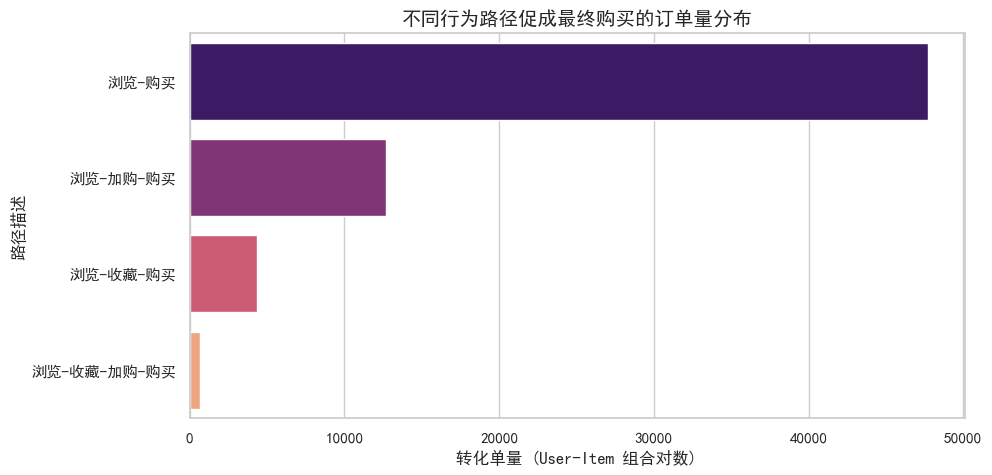

In [9]:
# 按用户-商品聚合，将四类行为出现与否标记为 1/0，拼接成路径编码
path_df = df_sample.groupby(['user_id', 'item_id'], observed=True)['behavior_type'].value_counts().unstack(fill_value=0).reset_index()
for col in ['pv', 'fav', 'cart', 'buy']:
    path_df[col] = path_df[col].apply(lambda x: '1' if x > 0 else '0')

path_df['path_code'] = path_df['pv'] + path_df['fav'] + path_df['cart'] + path_df['buy']

path_map = {'1001': '浏览-购买', '1101': '浏览-收藏-购买', '1011': '浏览-加购-购买', '1111': '浏览-收藏-加购-购买'}

path_summary = path_df['path_code'].value_counts().reset_index()
path_summary['路径描述'] = path_summary['path_code'].map(path_map)
buy_paths = path_summary.dropna().sort_values(by='count', ascending=False)

# 绘制各路径促成购买订单量的条形图
plt.figure(figsize=(10, 5))
sns.barplot(
    x='count', 
    y='路径描述', 
    data=buy_paths, 
    hue='路径描述', 
    palette='magma', 
    legend=False
)

plt.title('不同行为路径促成最终购买的订单量分布', fontsize=14, fontweight='bold')
plt.xlabel('转化单量 (User-Item 组合对数)')

plt.savefig(os.path.join(OUTPUTS_DIR, '05_behavior_path_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

3.用户动态复购周期与流失预警模型
通过计算用户每次购买到下一次购买的时间间隔，得到复购周期分布。
基于分位数设定预警线，用于识别可能流失的高危用户并及时干预。

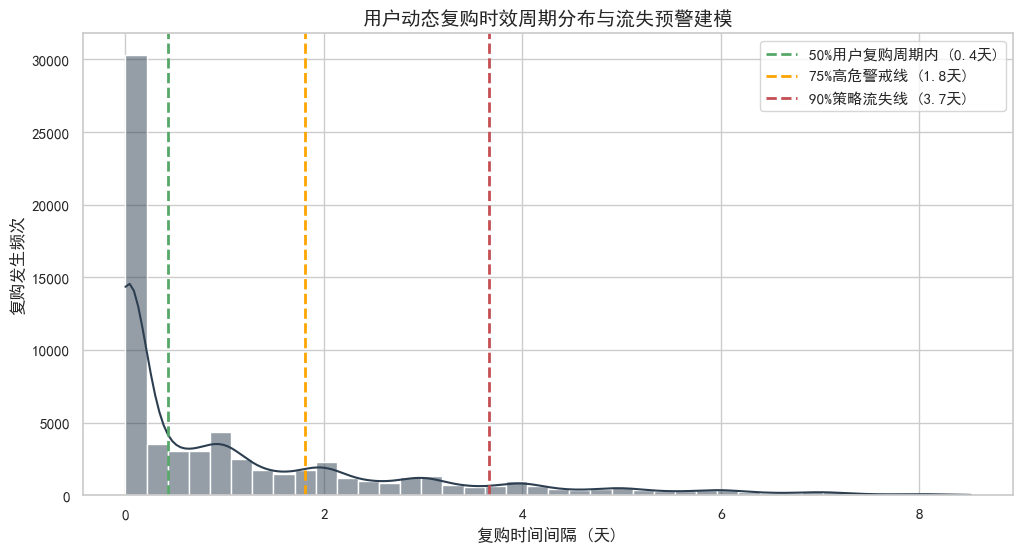

In [10]:
# 筛选购买行为，按用户和时间排序
df_buy_ts = df_sample[df_sample['behavior_type'] == 'buy'].copy().sort_values(by=['user_id', 'timestamp'])

# 计算每个用户下一次购买时间
df_buy_ts['next_buy_time'] = df_buy_ts.groupby('user_id')['timestamp'].shift(-1)

# 复购间隔（天）
df_buy_ts['repurchase_interval_days'] = (df_buy_ts['next_buy_time'] - df_buy_ts['timestamp']).dt.total_seconds() / 86400
intervals = df_buy_ts['repurchase_interval_days'].dropna()

# 设定预警分位数
p50, p75, p90 = intervals.median(), intervals.quantile(0.75), intervals.quantile(0.90)

# 绘制复购间隔分布及预警线
plt.figure(figsize=(12, 6))
sns.histplot(intervals, bins=40, kde=True, color='#2c3e50')
plt.axvline(p50, color='g', linestyle='--', linewidth=2, label=f'50%用户复购周期内 ({p50:.1f}天)')
plt.axvline(p75, color='orange', linestyle='--', linewidth=2, label=f'75%高危警戒线 ({p75:.1f}天)')
plt.axvline(p90, color='r', linestyle='--', linewidth=2, label=f'90%策略流失线 ({p90:.1f}天)')

plt.title('用户动态复购时效周期分布与流失预警建模', fontsize=14, fontweight='bold')
plt.xlabel('复购时间间隔 (天)')
plt.ylabel('复购发生频次')
plt.legend()

plt.savefig(os.path.join(OUTPUTS_DIR, '06_repurchase_interval_model.png'), dpi=300, bbox_inches='tight')
plt.show()